# Import Libraries

In [30]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

import joblib
from math import radians, sin, cos, sqrt, atan2

# Load Dataset

In [2]:
df = pd.read_csv(
    r"C:\Users\sanke\OneDrive\Documents\Fraud Detection System\Dataset\fraudTest.csv",
    low_memory=False
)

In [3]:
df.shape

(149999, 22)

# Basic EDA

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149999 entries, 0 to 149998
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   trans_date_trans_time  90000 non-null  object 
 1   cc_num                 90000 non-null  float64
 2   merchant               90000 non-null  object 
 3   category               90000 non-null  object 
 4   amt                    90000 non-null  float64
 5   first                  90000 non-null  object 
 6   last                   90000 non-null  object 
 7   gender                 90000 non-null  object 
 8   street                 90000 non-null  object 
 9   city                   90000 non-null  object 
 10  state                  90000 non-null  object 
 11  zip                    90000 non-null  float64
 12  lat                    90000 non-null  float64
 13  long                   90000 non-null  float64
 14  city_pop               90000 non-null  float64
 15  

In [5]:
df['is_fraud'].value_counts()

is_fraud
0.0    89632
1.0      368
Name: count, dtype: int64

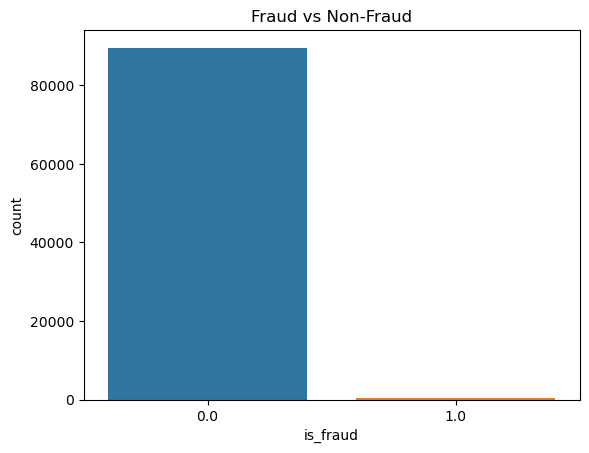

In [6]:
sns.countplot(x='is_fraud', data=df)
plt.title("Fraud vs Non-Fraud")
plt.show()

# Data Cleaning

In [7]:
df = df.drop(['first','last','street','trans_num','cc_num'], axis=1)

# Feature Engineering

In [8]:
df['trans_date_trans_time'] = pd.to_datetime(
    df['trans_date_trans_time'],
    dayfirst=True
)

df['hour'] = df['trans_date_trans_time'].dt.hour
df['day'] = df['trans_date_trans_time'].dt.day
df['month'] = df['trans_date_trans_time'].dt.month
df['is_weekend'] = df['trans_date_trans_time'].dt.weekday >= 5

In [9]:
df['dob'] = pd.to_datetime(df['dob'], format="%d-%m-%Y")

df['age'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365

In [10]:
def haversine(lat1, lon1, lat2, lon2):
    
    R = 6371
    
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    
    return R * c


df['distance_km'] = df.apply(
    lambda x: haversine(x['lat'], x['long'], x['merch_lat'], x['merch_long']),
    axis=1
)

# Drop Columns After Feature Engineering

In [11]:
df = df.drop(['trans_date_trans_time','dob','lat','long','merch_lat','merch_long'], axis=1)

# Encoding Categorical Features

In [12]:
categorical_cols = ['merchant','category','gender','city','state','job']

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Data Cleaning

In [13]:
df['is_fraud'].isna().sum()

59999

In [14]:
df[df['is_fraud'].isna()]

,merchant,category,amt,gender,city,state,zip,city_pop,job,unix_time,is_fraud,hour,day,month,is_weekend,age,distance_km
90000,693,14,NaN,2,839,50,NaN,NaN,476,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN
90001,693,14,NaN,2,839,50,NaN,NaN,476,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN
90002,693,14,NaN,2,839,50,NaN,NaN,476,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN
90003,693,14,NaN,2,839,50,NaN,NaN,476,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN
90004,693,14,NaN,2,839,50,NaN,NaN,476,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149994,693,14,NaN,2,839,50,NaN,NaN,476,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN
149995,693,14,NaN,2,839,50,NaN,NaN,476,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN
149996,693,14,NaN,2,839,50,NaN,NaN,476,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN
149997,693,14,NaN,2,839,50,NaN,NaN,476,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN


In [15]:
df = df.dropna(subset=['is_fraud'])

In [16]:
df['is_fraud'] = df['is_fraud'].astype(int)

# Train Test Split

In [17]:
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Handle Imbalanced Data (SMOTE)

In [18]:
smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Feature Scaling

In [19]:
scaler = StandardScaler()

X_train_sm = scaler.fit_transform(X_train_sm)
X_test = scaler.transform(X_test)

# Define Models

In [20]:
models = {

"Logistic Regression": LogisticRegression(max_iter=200),

"Decision Tree": DecisionTreeClassifier(),

"Random Forest": RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
),

"XGBoost": XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    eval_metric="logloss"
)

}

# Train Models and Compare Performance

In [21]:
results = []

for name, model in models.items():
    
    model.fit(X_train_sm, y_train_sm)
    
    y_pred = model.predict(X_test)
    
    y_prob = model.predict_proba(X_test)[:,1]
    
    acc = accuracy_score(y_test, y_pred)
    
    precision = precision_score(y_test, y_pred)
    
    recall = recall_score(y_test, y_pred)
    
    f1 = f1_score(y_test, y_pred)
    
    roc = roc_auc_score(y_test, y_prob)
    
    results.append([name, acc, precision, recall, f1, roc])

# Model Comparison Table

In [22]:
results_df = pd.DataFrame(results, columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC AUC"
])

results_df.sort_values(by="ROC AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
3,XGBoost,0.996222,0.523438,0.905405,0.663366,0.998095
2,Random Forest,0.978056,0.142539,0.864865,0.244742,0.982842
0,Logistic Regression,0.928222,0.044162,0.797297,0.083688,0.874277
1,Decision Tree,0.991278,0.278075,0.702703,0.398467,0.847586


# Select Best Model

In [23]:
best_model_name = results_df.sort_values(by="ROC AUC", ascending=False).iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: XGBoost


In [24]:
# Train Best Model Again

In [25]:
best_model = models[best_model_name]

best_model.fit(X_train_sm, y_train_sm)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None,
              num_parallel_tree=None, ...)

# Evaluation of Best Model

In [26]:
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     17926
           1       0.52      0.91      0.66        74

    accuracy                           1.00     18000
   macro avg       0.76      0.95      0.83     18000
weighted avg       1.00      1.00      1.00     18000



# SHAP Explainability

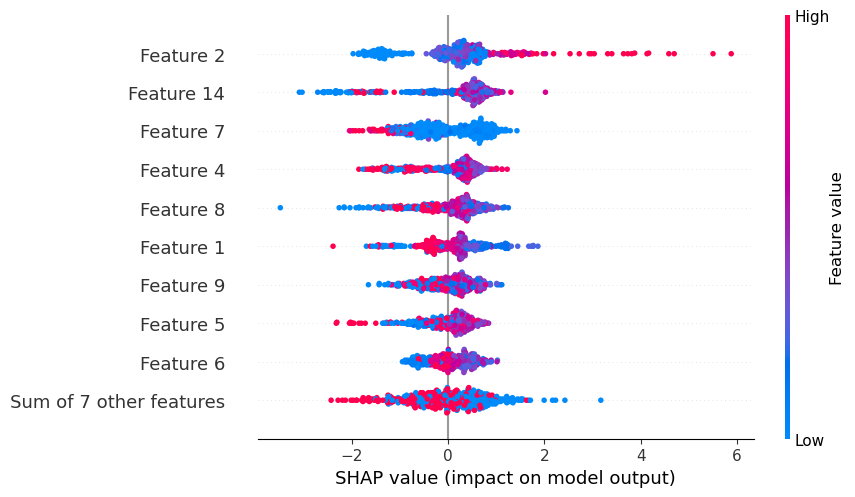

In [33]:
X_sample = X_test[:500]

explainer = shap.Explainer(best_model, X_sample)

shap_values = explainer(X_sample)

shap.plots.beeswarm(shap_values)

# Save Model

In [35]:
joblib.dump(best_model, "fraud_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']